In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import json
from pathlib import Path

os.chdir("/home/kaariaa3/mscthesis/")
sys.path.append("./src/")  # Add module directory to path

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from utils.tools import aggregate_results

In [3]:
def get_suite(row):

    n_demos = row["number of demonstrations"]
    type_demos = row["type of demonstrations"][0:3]
    instr = "impl" if row["use instructions"] == "no" else "expl"

    return f"{n_demos}-{type_demos}-{instr}"

def order_models(strings, rev=False):
    return sorted(strings, key=lambda s: (
        s.split('-')[0],  # Model name
        -1 * int(s.split('-')[1][:-1]),  # Param count, B dropped
    ), reverse=rev)

def capitalize(s):
    return s[0].upper() + s[1:]

In [4]:
def my_catplot(df, metric_cols, kind="box", err="sd"):
    
    # Convert to long format
    plot_df = pd.DataFrame({
        'model': df['model'].tolist() * 3,
        'metric': (['Theme'] * len(df) +
                   ['Topic'] * len(df) +
                   ['Concept'] * len(df)),
        'mean': pd.concat([df[col] for col in metric_cols_f1], ignore_index=True)
    })

    # Figure
    g = sns.catplot(
        data=plot_df,
        order=order_models(res["model"].unique()),
        x='model',
        y='mean',
        hue='metric',
        kind=kind,
        errorbar=err,
        height=5,
        aspect=1.2,
    )

    # Labels & formatting
    sns.move_legend(g, "upper left", frameon=True, bbox_to_anchor=(0.1, 0.43))
    g.set_axis_labels("Model", "F1 Score")
    g.set_xticklabels(rotation=45)
    g.set(ylim=(0, 1))

    #plt.legend()
    plt.tight_layout()

    return g

In [5]:
metric_cols_f1 = ["theme f1 mean", "topic f1 mean", "concept f1 mean"]
metric_cols_prec = ["theme precision mean", "topic precision mean", "concept precision mean"]
metric_cols_rec = ["theme recall mean", "topic recall mean", "concept recall mean"]

res = pd.read_csv("./data/metrics_v3.csv", sep=";")
res = res.sort_values(by=["use instructions", "number of demonstrations", "type of demonstrations"])
res["suite"] = res.apply(get_suite, axis=1)

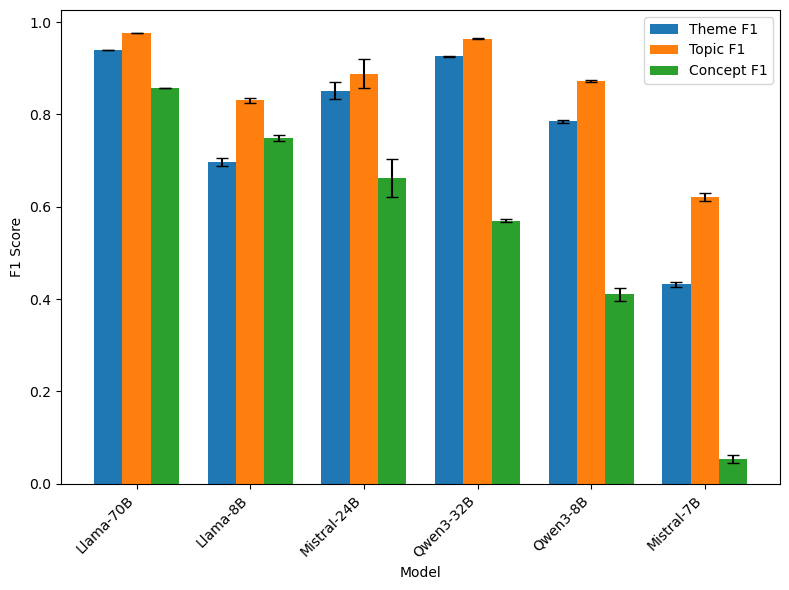

In [6]:
baselines = res[res["suite"] == "0-non-expl"]

# Sort for cleaner plotting
df_plot = baselines.sort_values("concept f1 mean", ascending=False)

x = np.arange(len(df_plot))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 6))

# Theme F1
ax.bar(
    x - width,
    df_plot["theme f1 mean"],
    width,
    yerr=df_plot["theme f1 std"],
    capsize=4,
    label="Theme F1"
)

# Topic F1
ax.bar(
    x,
    df_plot["topic f1 mean"],
    width,
    yerr=df_plot["topic f1 std"],
    capsize=4,
    label="Topic F1"
)

# Concept F1
ax.bar(
    x + width,
    df_plot["concept f1 mean"],
    width,
    yerr=df_plot["concept f1 std"],
    capsize=4,
    label="Concept F1"
)

ax.set_xticks(x)
ax.set_xticklabels(df_plot["model"], rotation=45, ha="right")

ax.set_ylabel("F1 Score")
ax.set_xlabel("Model")
ax.set_title("")
ax.legend()

plt.tight_layout()
#plt.show()

plt.savefig("./latex/images/baselines_f1_v2.png")